In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity


In [15]:
data = {
    "User": ["U1","U1","U1","U2","U2","U3","U3","U4","U4","U5"],
    "Movie": ["M1","M2","M3","M1","M3","M2","M4","M1","M4","M3"],
    "Rating": [5,4,3,5,4,4,5,3,4,5]
}

df = pd.DataFrame(data)
df


,User,Movie,Rating
0,U1,M1,5
1,U1,M2,4
2,U1,M3,3
3,U2,M1,5
4,U2,M3,4
5,U3,M2,4
6,U3,M4,5
7,U4,M1,3
8,U4,M4,4
9,U5,M3,5


In [16]:
user_item_matrix = df.pivot_table(
    index="User",
    columns="Movie",
    values="Rating"
).fillna(0)

user_item_matrix


Movie,M1,M2,M3,M4
User,,,,
U1,5.0,4.0,3.0,0.0
U2,5.0,0.0,4.0,0.0
U3,0.0,4.0,0.0,5.0
U4,3.0,0.0,0.0,4.0
U5,0.0,0.0,5.0,0.0


In [17]:
user_similarity = cosine_similarity(user_item_matrix)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

user_similarity_df


User,U1,U2,U3,U4,U5
User,,,,,
U1,1.000000,0.817193,0.353381,0.424264,0.424264
U2,0.817193,1.000000,0.000000,0.468521,0.624695
U3,0.353381,0.000000,1.000000,0.624695,0.000000
U4,0.424264,0.468521,0.624695,1.000000,0.000000
U5,0.424264,0.624695,0.000000,0.000000,1.000000


In [18]:
def recommend_movies(user, num_recommendations=2):
    user_index = user_item_matrix.index.get_loc(user)
    
    similarity_scores = user_similarity_df.iloc[user_index]
    similar_users = similarity_scores.sort_values(ascending=False)[1:]
    
    weighted_ratings = np.zeros(user_item_matrix.shape[1])
    similarity_sum = 0
    
    for sim_user, sim_score in similar_users.items():
        weighted_ratings += sim_score * user_item_matrix.loc[sim_user].values
        similarity_sum += sim_score
    
    recommendations = weighted_ratings / similarity_sum
    
    movie_scores = pd.Series(
        recommendations,
        index=user_item_matrix.columns
    )
    
    watched_movies = user_item_matrix.loc[user] > 0
    movie_scores = movie_scores[~watched_movies]
    
    return movie_scores.sort_values(ascending=False).head(num_recommendations)


In [19]:
recommendations = recommend_movies("U1", num_recommendations=3)
recommendations


Movie
M4    1.715594
dtype: float64

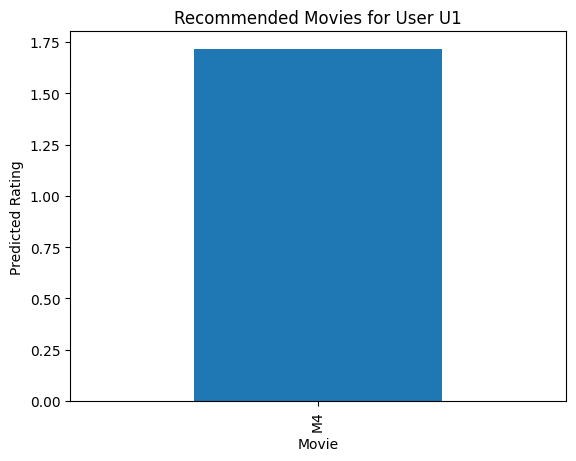

In [20]:
recommendations.plot(kind='bar', title="Recommended Movies for User U1")
plt.ylabel("Predicted Rating")
plt.show()


In [21]:
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

actual = np.array([5,4,3])
predicted = np.array([4.5,4.1,3.2])

print("RMSE:", rmse(actual, predicted))


RMSE: 0.31622776601683794
